# Лабораторна робота №1
## Робота з файловою системою Linux та багатопоточне читання файлів засобами Python
**Дисципліна:** Операційні системи та системне програмування  
**Студент:** Кусік  
**Рік:** 2026

In [3]:
import os
import random
import threading
import time
from pathlib import Path

import matplotlib.pyplot as plt

RANDOM_STATE = 42
FIGURES_DIR = "figures"

random.seed(RANDOM_STATE)

test_sizes = [100, 300, 500]
lines_per_file = 1000

word_pool = [
    "linux", "python", "thread", "file", "system", "process", "input",
    "output", "random", "text", "analysis", "performance", "pathlib",
    "module", "directory", "access", "mode", "data", "sequential",
    "parallel", "testing", "result", "character", "line", "word"
]

## Частина 1. Створення структури каталогу

In [4]:
base = Path("lab_os_1")
input_dir = base / "input"
output_dir = base / "output"
logs_dir = base / "logs"

for d in [base, input_dir, output_dir, logs_dir]:
    d.mkdir(exist_ok=True)

os.chmod(base, 0o755)
os.chmod(input_dir, 0o755)
os.chmod(output_dir, 0o755)
os.chmod(logs_dir, 0o700)

print("Directory structure created:")
for d in [base, input_dir, output_dir, logs_dir]:
    print(f"  {d}  mode={oct(os.stat(d).st_mode)[-3:]}")

Directory structure created:
  lab_os_1  mode=777
  lab_os_1/input  mode=777
  lab_os_1/output  mode=777
  lab_os_1/logs  mode=777


## Частина 2. Генерація тестових файлів

In [5]:
def generate_random_line():
    return " ".join(random.choice(word_pool) for _ in range(random.randint(8, 16)))


def generate_test_files(file_count):
    for f in input_dir.glob("*.txt"):
        f.unlink()
    for i in range(1, file_count + 1):
        with open(input_dir / f"file_{i}.txt", "w", encoding="utf-8") as f:
            for _ in range(lines_per_file):
                f.write(generate_random_line() + "\n")
    print(f"Generated {file_count} files in {input_dir}")

## Частина 3. Послідовна обробка файлів

In [6]:
sequential_result_file = output_dir / "result_sequential.txt"


def analyze_file(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    lines = len(text.splitlines())
    words = len(text.split())
    chars = len(text)
    return f"{path.name}  lines={lines}  words={words}  chars={chars}"


def run_sequential(file_count):
    start = time.perf_counter()
    results = [analyze_file(f) for f in sorted(input_dir.glob("*.txt"))]
    elapsed = time.perf_counter() - start

    with open(sequential_result_file, "a", encoding="utf-8") as f:
        f.write(f"=== {file_count} files ===\n")
        f.write("\n".join(results) + "\n\n")

    return elapsed

## Частина 4. Багатопоточна обробка файлів

In [7]:
threads_result_file = output_dir / "result_threads.txt"


def run_threaded(file_count):
    start = time.perf_counter()
    results = []
    lock = threading.Lock()

    def worker(path):
        result = analyze_file(path)
        with lock:
            results.append(result)

    threads = [threading.Thread(target=worker, args=(f,)) for f in input_dir.glob("*.txt")]
    for t in threads:
        t.start()
    for t in threads:
        t.join()

    elapsed = time.perf_counter() - start

    with open(threads_result_file, "a", encoding="utf-8") as f:
        f.write(f"=== {file_count} files ===\n")
        f.write("\n".join(sorted(results)) + "\n\n")

    return elapsed

## Частина 5. Порівняння продуктивності

In [8]:
# Очищення попередніх результатів
for path in [sequential_result_file, threads_result_file]:
    path.write_text("", encoding="utf-8")

seq_times = []
thr_times = []

print(f"{'Files':>6} | {'Sequential':>12} | {'Threaded':>12}")
print("-" * 38)

for size in test_sizes:
    generate_test_files(size)
    seq = run_sequential(size)
    thr = run_threaded(size)
    seq_times.append(seq)
    thr_times.append(thr)
    print(f"{size:>6} | {seq:>10.4f}s | {thr:>10.4f}s")

 Files |   Sequential |     Threaded
--------------------------------------
Generated 100 files in lab_os_1/input
   100 |     0.1880s |     0.0734s
Generated 300 files in lab_os_1/input
   300 |     0.5519s |     0.2016s
Generated 500 files in lab_os_1/input
   500 |     1.1499s |     0.3331s


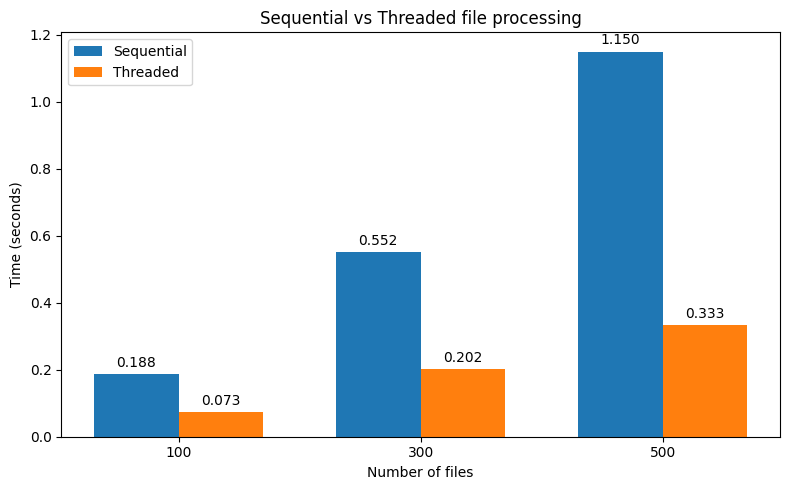

Figure saved to figures/performance_comparison.png


In [9]:
os.makedirs(FIGURES_DIR, exist_ok=True)

x = range(len(test_sizes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width / 2 for i in x], seq_times, width, label="Sequential")
bars2 = ax.bar([i + width / 2 for i in x], thr_times, width, label="Threaded")

ax.set_xlabel("Number of files")
ax.set_ylabel("Time (seconds)")
ax.set_title("Sequential vs Threaded file processing")
ax.set_xticks(list(x))
ax.set_xticklabels([str(s) for s in test_sizes])
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/performance_comparison.png", dpi=150)
plt.show()
print(f"Figure saved to {FIGURES_DIR}/performance_comparison.png")